# Global Cybersecurity Threats Analysis

## **Load Libraries**

In [1]:
import numpy as np
import pandas as pd
from datetime import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

## **Load Data**

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("atharvasoundankar/global-cybersecurity-threats-2015-2024")

print("Path to dataset files:", path)

100%|██████████| 47.0k/47.0k [00:00<00:00, 18.5MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/atharvasoundankar/global-cybersecurity-threats-2015-2024/versions/1


In [5]:
from google.colab import files

uploaded = files.upload()

Saving Global_Cybersecurity_Threats_2015-2024.csv to Global_Cybersecurity_Threats_2015-2024.csv


In [7]:
df = pd.read_csv('Global_Cybersecurity_Threats_2015-2024.csv')

df.head(10)

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68
5,Germany,2017,Man-in-the-Middle,Retail,98.24,285201,Unknown,Social Engineering,Antivirus,25
6,Germany,2016,DDoS,Telecommunications,33.26,431262,Insider,Unpatched Software,VPN,34
7,France,2018,SQL Injection,Government,59.23,909991,Unknown,Social Engineering,Antivirus,66
8,India,2016,Man-in-the-Middle,Banking,16.88,698249,Unknown,Social Engineering,VPN,47
9,UK,2023,DDoS,Healthcare,69.14,685927,Hacker Group,Unpatched Software,Firewall,58


## **Explore Data**

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Country                              3000 non-null   object 
 1   Year                                 3000 non-null   int64  
 2   Attack Type                          3000 non-null   object 
 3   Target Industry                      3000 non-null   object 
 4   Financial Loss (in Million $)        3000 non-null   float64
 5   Number of Affected Users             3000 non-null   int64  
 6   Attack Source                        3000 non-null   object 
 7   Security Vulnerability Type          3000 non-null   object 
 8   Defense Mechanism Used               3000 non-null   object 
 9   Incident Resolution Time (in Hours)  3000 non-null   int64  
dtypes: float64(1), int64(3), object(6)
memory usage: 234.5+ KB


In [9]:
df.shape

(3000, 10)

In [11]:
df.dtypes

,0
Country,object
Year,int64
Attack Type,object
Target Industry,object
Financial Loss (in Million $),float64
Number of Affected Users,int64
Attack Source,object
Security Vulnerability Type,object
Defense Mechanism Used,object
Incident Resolution Time (in Hours),int64


In [12]:
df.nunique()

,0
Country,10
Year,10
Attack Type,6
Target Industry,7
Financial Loss (in Million $),2536
Number of Affected Users,2998
Attack Source,4
Security Vulnerability Type,4
Defense Mechanism Used,5
Incident Resolution Time (in Hours),72


In [13]:
df.isnull().sum()

,0
Country,0
Year,0
Attack Type,0
Target Industry,0
Financial Loss (in Million $),0
Number of Affected Users,0
Attack Source,0
Security Vulnerability Type,0
Defense Mechanism Used,0
Incident Resolution Time (in Hours),0


In [14]:
df['Country'] = df['Country'].astype('|S')
df['Attack Type'] = df['Attack Type'].astype('|S')
df['Target Industry'] = df['Target Industry'].astype('|S')
df['Attack Source'] = df['Attack Source'].astype('|S')
df['Security Vulnerability Type'] = df['Security Vulnerability Type'].astype('|S')
df['Defense Mechanism Used'] = df['Defense Mechanism Used'].astype('|S')

df.dtypes

,0
Country,|S9
Year,int64
Attack Type,|S17
Target Industry,|S18
Financial Loss (in Million $),float64
Number of Affected Users,int64
Attack Source,|S12
Security Vulnerability Type,|S18
Defense Mechanism Used,|S18
Incident Resolution Time (in Hours),int64


## **Number Affected User By Source Attack**

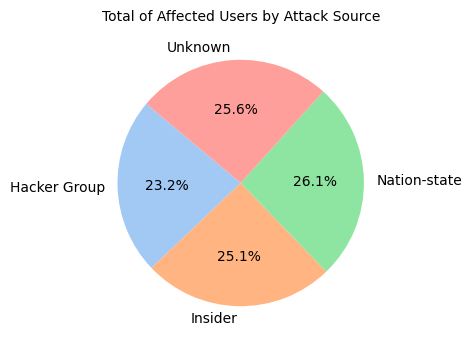

In [17]:
attack_summary = df.groupby('Attack Source')['Number of Affected Users'].sum()
labels = [label.decode('utf-8') if isinstance(label, bytes) else label for label in attack_summary.index] # Labels and values
values = attack_summary.values
colors = sns.color_palette("pastel")
plt.figure(figsize=(4, 4)) # Plot
plt.pie(values, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Total of Affected Users by Attack Source', fontsize=10)
print()
plt.show()

## **Number Affected User By Attack Type**

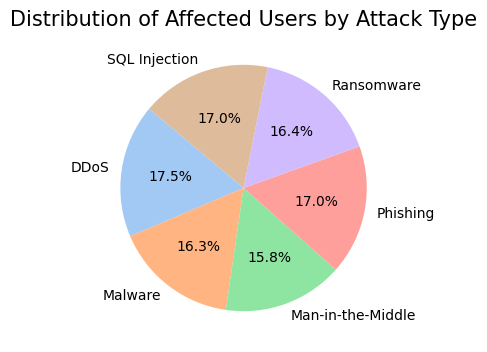

In [18]:
attack_summary = df.groupby('Attack Type')['Number of Affected Users'].sum()
labels = [label.decode('utf-8') if isinstance(label, bytes) else label for label in attack_summary.index] # Labels and values
values = attack_summary.values
colors = sns.color_palette("pastel")
plt.figure(figsize=(4, 4)) # Plot
plt.pie(values, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Affected Users by Attack Type', fontsize=15)
print()
plt.show()

# **Financial Loss By Year**

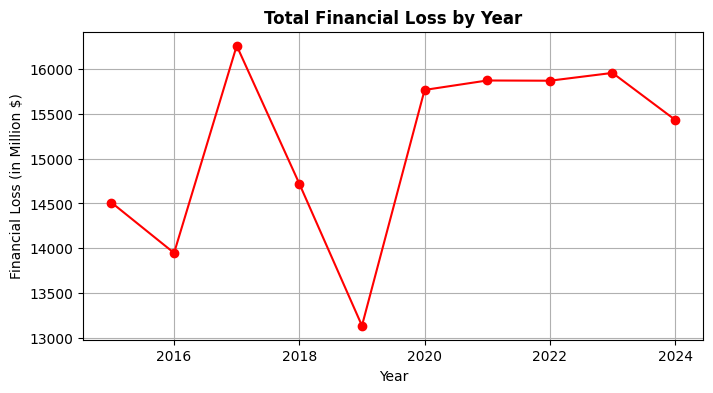

In [19]:
yearly  = df.groupby('Year')['Financial Loss (in Million $)'].sum().reset_index()
plt.figure(figsize=(8, 4)) # Plot
plt.plot(yearly['Year'], yearly['Financial Loss (in Million $)'], marker='o', linestyle='-', color='r')
plt.title("Total Financial Loss by Year", fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Financial Loss (in Million $)")
plt.grid(True)
plt.show()

## **Number Of Affected Users In Year**

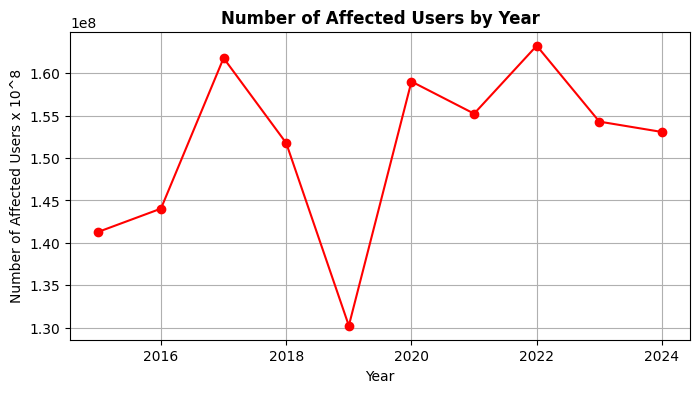

In [20]:
yearly = df.groupby('Year')['Number of Affected Users'].sum().reset_index()
plt.figure(figsize=(8, 4)) # Plot
plt.plot(yearly['Year'], yearly['Number of Affected Users'], marker='o', linestyle='-', color='r')
plt.title("Number of Affected Users by Year", fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Number of Affected Users x 10^8")
plt.grid(True)
plt.show()

## **Financial Loss By Country**

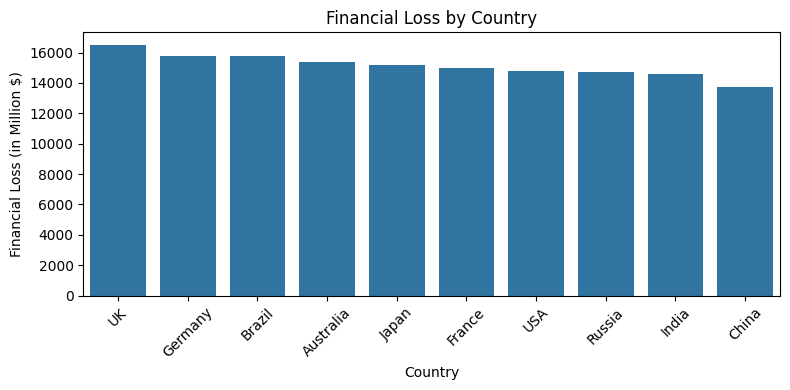

In [21]:
df["Country"] = df["Country"].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)
sorted_data = df.groupby("Country", as_index=False)["Financial Loss (in Million $)"].sum()
sorted_data = sorted_data.sort_values(by="Financial Loss (in Million $)", ascending=False)
plt.figure(figsize=(8, 4))
sns.barplot(data=sorted_data, x="Country", y="Financial Loss (in Million $)")
plt.xticks(rotation=45)
plt.title("Financial Loss by Country")
plt.tight_layout()
plt.show()

## **Financial Loss By Attack Type**

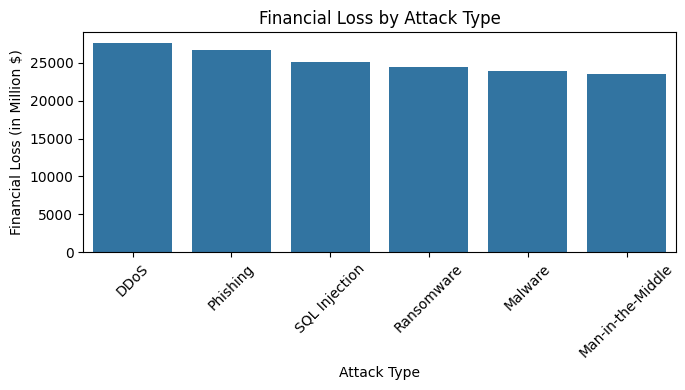

In [22]:
df["Attack Type"] = df["Attack Type"].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes)                                                 else x)
sorted_data = df.groupby("Attack Type", as_index=False)["Financial Loss (in Million $)"].sum()
sorted_data = sorted_data.sort_values(by="Financial Loss (in Million $)", ascending=False)
plt.figure(figsize=(7, 4))
sns.barplot(data=sorted_data, x="Attack Type", y="Financial Loss (in Million $)")
plt.xticks(rotation=45)
plt.title("Financial Loss by Attack Type")
plt.tight_layout()
plt.show()

## **Financial Loss By Target Industry**

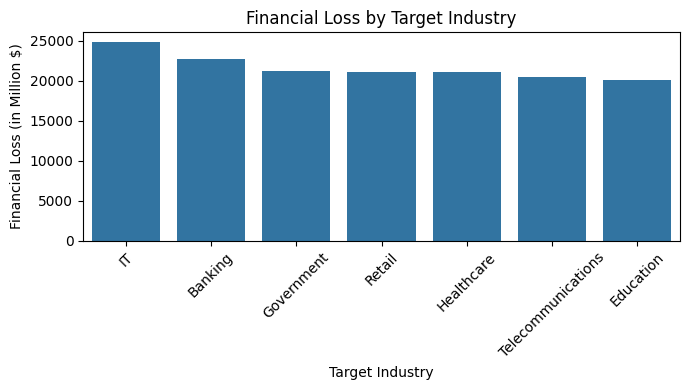

In [23]:
df["Target Industry"] = df["Target Industry"].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes)
                                                else x)
sorted_data = df.groupby("Target Industry", as_index=False)["Financial Loss (in Million $)"].sum()
sorted_data = sorted_data.sort_values(by="Financial Loss (in Million $)", ascending=False)
plt.figure(figsize=(7, 4))
sns.barplot(data=sorted_data, x="Target Industry", y="Financial Loss (in Million $)")
plt.xticks(rotation=45)
plt.title("Financial Loss by Target Industry")
plt.tight_layout()
plt.show()

## **Average Incident Resolution Time By Year**

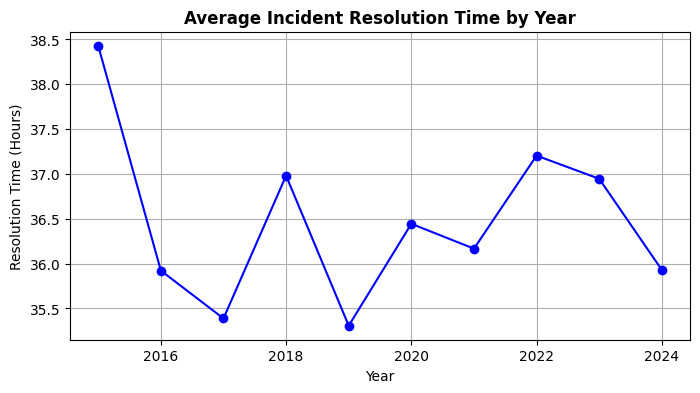

In [24]:
yearly_avg = df.groupby('Year')['Incident Resolution Time (in Hours)'].mean().reset_index()
plt.figure(figsize=(8, 4)) # Plot
plt.plot(yearly_avg['Year'], yearly_avg['Incident Resolution Time (in Hours)'], marker='o',
         linestyle='-',color='b')
plt.title("Average Incident Resolution Time by Year", fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Resolution Time (Hours)")
plt.grid(True)
plt.show()

## **EDA** 📉📊📈

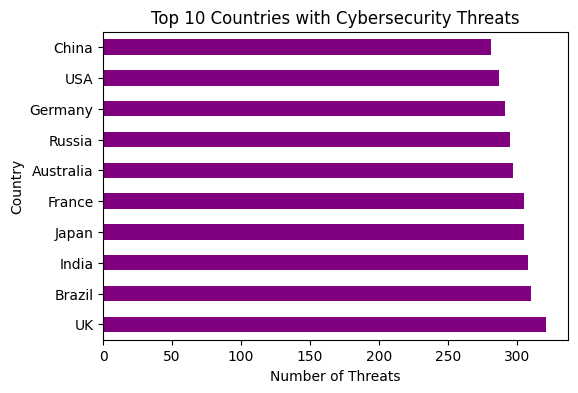

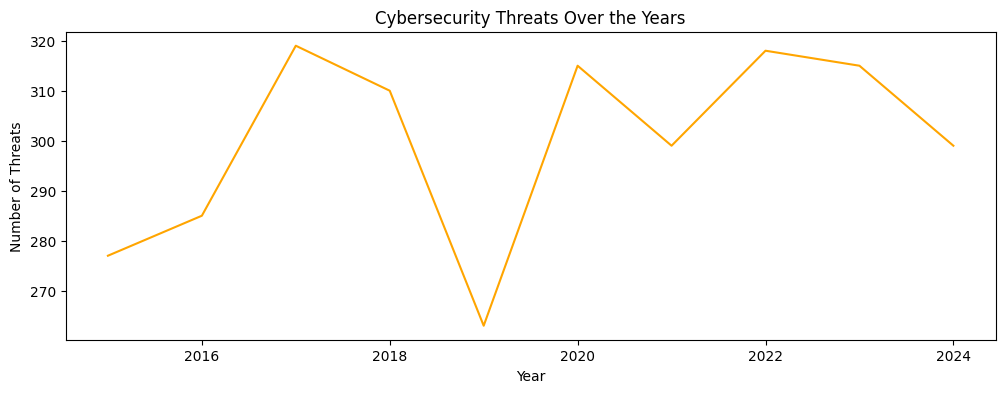

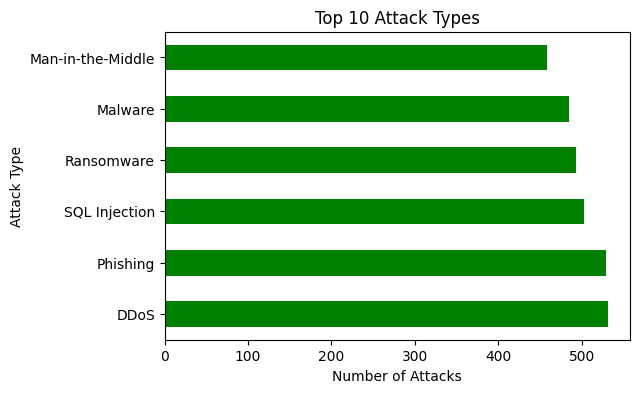

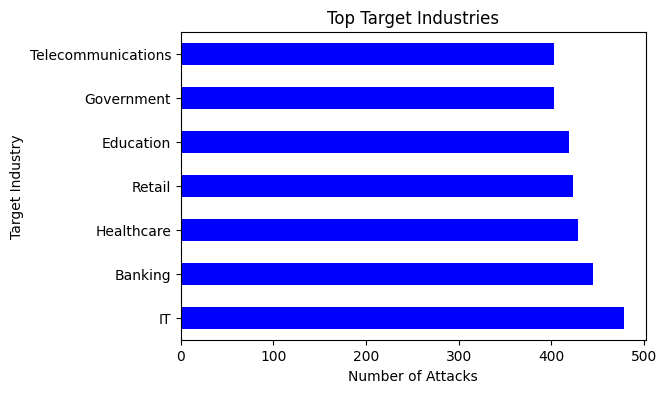

/tmp/ipython-input-25-3765770438.py:31: FutureWarning: The behavior of value_counts with object-dtype is deprecated. In a future version, this will *not* perform dtype inference on the resulting index. To retain the old behavior, use `result.index = result.index.infer_objects()`
  df["Attack Source"].value_counts().plot(kind = "barh", figsize = (6, 4), color = "red")


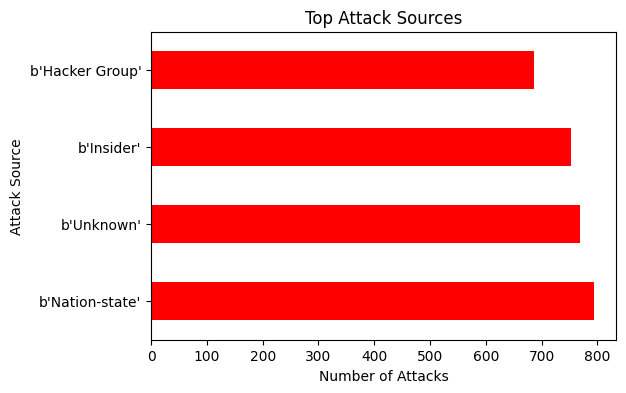

/tmp/ipython-input-25-3765770438.py:38: FutureWarning: The behavior of value_counts with object-dtype is deprecated. In a future version, this will *not* perform dtype inference on the resulting index. To retain the old behavior, use `result.index = result.index.infer_objects()`
  df["Security Vulnerability Type"].value_counts().head(10).plot(kind = "barh", figsize = (6, 4), color = "pink")


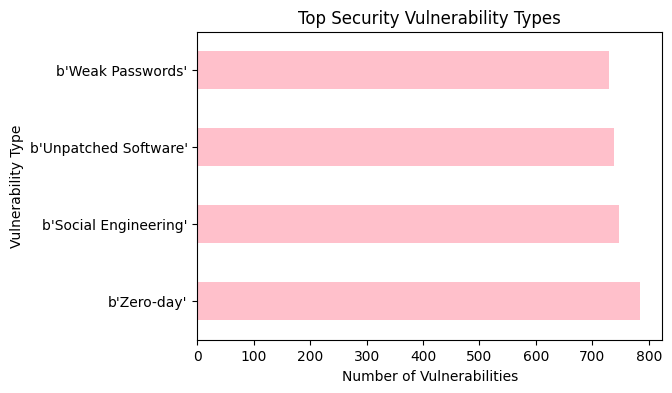

/tmp/ipython-input-25-3765770438.py:45: FutureWarning: The behavior of value_counts with object-dtype is deprecated. In a future version, this will *not* perform dtype inference on the resulting index. To retain the old behavior, use `result.index = result.index.infer_objects()`
  df["Defense Mechanism Used"].value_counts().head(10).plot(kind = "barh", figsize = (6, 4), color = "brown")


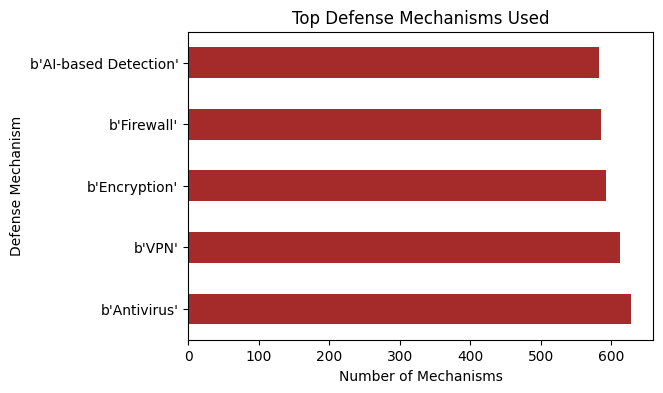

In [25]:
# Count the number of unique values in each column
# First count of unique in  country values
df["Country"].value_counts().head(10).plot(kind = "barh", figsize = (6, 4), color = "purple")
plt.title("Top 10 Countries with Cybersecurity Threats")
plt.xlabel("Number of Threats")
plt.ylabel("Country")
plt.show()

# Count  of Years
df["Year"].value_counts().sort_index().plot(kind="line", figsize=(12, 4), color="orange")
plt.title("Cybersecurity Threats Over the Years")
plt.xlabel("Year")
plt.ylabel("Number of Threats")
plt.show()

# Count of unique values in  attack types
df["Attack Type"].value_counts().plot(kind = "barh", figsize = (6, 4), color = "green")
plt.title("Top 10 Attack Types")
plt.xlabel("Number of Attacks")
plt.ylabel("Attack Type")
plt.show()

# Count of unique values in  attack types
df["Target Industry"].value_counts().head(10).plot(kind = "barh", figsize = (6, 4), color = "blue")
plt.title("Top Target Industries")
plt.xlabel("Number of Attacks")
plt.ylabel("Target Industry")
plt.show()

# Count of unique values in  attack types
df["Attack Source"].value_counts().plot(kind = "barh", figsize = (6, 4), color = "red")
plt.title("Top Attack Sources")
plt.xlabel("Number of Attacks")
plt.ylabel("Attack Source")
plt.show()

# Count of unique values in  Security Vulnerability Type
df["Security Vulnerability Type"].value_counts().head(10).plot(kind = "barh", figsize = (6, 4), color = "pink")
plt.title("Top Security Vulnerability Types")
plt.xlabel("Number of Vulnerabilities")
plt.ylabel("Vulnerability Type")
plt.show()

# Count of unique values in Defense Mechanism Used
df["Defense Mechanism Used"].value_counts().head(10).plot(kind = "barh", figsize = (6, 4), color = "brown")
plt.title("Top Defense Mechanisms Used")
plt.xlabel("Number of Mechanisms")
plt.ylabel("Defense Mechanism")
plt.show()

### **3.- Top Cybersecurity Attack Types:**


1. **DDoS:**

> DDoS (Distributed Denial of Service) is a cyber attack.
        It overwhelms a system with traffic from multiple sources.
        Attackers use botnets to flood the target with traffic.
        This causes resource exhaustion, making the system unavailable.
        DDoS attacks can lead to downtime, financial losses, and data breaches.

2. **Phishing:**

> Phishing is a cybercrime where attackers, posing as legitimate entities, use fraudulent emails, text messages, or phone calls         to trick individuals into revealing sensitive information like passwords, financial details, or personal data.

3. **SQL Injection:**

> Structured Query Language (SQL) injection is an attack technique that attempts to subvert the relationship between a webpage and its supporting database, typically in order to trick the database into executing malicious code.

4. **Ransomware:**

> Ransomware is malware that encrypts files or locks devices.
       Attackers demand a ransom for decryption or unlock codes.
       Types include crypto-ransomware, locker ransomware, and doxware.
       Consequences include data loss, financial loss, and reputational damage.
       Prevention involves backups, software updates, antivirus software, and employee education.

5. **Malware:**

> Malware is malicious software that harms or exploits devices.
      Types include viruses, worms, trojans, ransomware, and spyware.
      Malware attacks can steal data, disrupt systems, or demand ransom.
      Attacks often occur through phishing, downloads, or vulnerabilities.
      Prevention involves antivirus software, updates, and safe computing practices.

6. **Man-in-the-Middle:**

>  man-in-the-middle (MITM) attack is a cyberattack where an attacker intercepts and potentially alters communication between two parties, pretending to be one of them to steal sensitive information or disrupt the conversation.